# TechTrack use case 

# Task 5: Hard Negative Mining (HNM) λ Sensitivity Analysis
## How different λ values affect which images are sampled as 'hard'?

**Hard Negative Mining (HNM)** is a data selection strategy that focuses training or analysis on the examples a model currently finds most difficult. Instead of sampling images uniformly, HNM assigns each image a hardness score (typically derived from a loss function), ranks the dataset by that score, and then selects a top fraction (or top-K) as the hard subset. This hard subset can be used to target failure cases, accelerate learning on difficult scenarios, and improve performance on under-represented or challenging conditions.

In our implementation, the hardness score is computed using a modified YOLO-style loss that combines multiple error types (localization, objectness for true objects, objectness for background/no-object, and classification). The λ weights control how much each component contributes to the total loss, so changing λ directly changes the hardness ranking. For example, if we increase the weight on the no-object term, images with many false positives become "harder" and will be mined more often; if we increase the weight on the objectness term, images with missed detections become the primary focus. In other words, λ defines what "hard" means, and HNM will sample different kinds of images depending on which failure mode we choose to emphasize.

This notebook analyzes how changing the loss weights (λ) in our modified YOLO loss impacts the ranking of hard images selected by Hard Negative Mining.

### Intuition
- Increasing **λ_coord** prioritizes images with **poor localization** (shifted/incorrect boxes)
- Increasing **λ_obj**   prioritizes **missed objects** (low objectness for true objects / false negatives)
- Increasing **λ_noobj**  prioritizes **false positives** (high objectness where no GT match)
- increasing **λ_cls**  prioritizes **misclassification** (wrong class scores)

This notebook:

1) Loads cached **Model 2** detections (or compute if missing).
2) Converts detections and labels into the Loss module’s expected format (xyxy + scores).
3) Sweeps different λ configurations.
4) For each configuration, computes per-image loss and select top-K hard images.
5) Compares sampled image sets and summarize what changes (classes, small objects, density, FP/FN-heavy images).


In [2]:

import os, glob, pickle
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

try:
    from tqdm import tqdm
except Exception:
    tqdm = lambda x, **k: x

import sys
from pathlib import Path

TECHTRACK_DIR = Path.cwd().parent / "techtrack"
sys.path.insert(0, str(TECHTRACK_DIR))

from modules.inference.model import Detector
from modules.inference.nms import NMS
from modules.utils.loss import Loss


## 1) Paths and configuration

In [4]:
REPO_ROOT = os.getcwd()

DATASET_DIR = Path(REPO_ROOT) / "analysis_cache_sampling" / "sampled_subset"
assert DATASET_DIR.is_dir(), f"Dataset not found: {DATASET_DIR.resolve()}"

MODELS_DIR = Path(TECHTRACK_DIR) / "storage" / "yolo_models"
assert MODELS_DIR.is_dir(), f"Models dir not found: {MODELS_DIR.resolve()}"

MODEL2_CFG = MODELS_DIR / "yolov4-tiny-logistics_size_416_2.cfg"
MODEL2_WEIGHTS = MODELS_DIR / "yolov4-tiny-logistics_size_416_2.weights"

CLASS_NAMES_PATH = MODELS_DIR / "logistics.names"
if not CLASS_NAMES_PATH.exists():
    CLASS_NAMES_PATH = DATASET_DIR / "logistics.names"

assert MODEL2_CFG.exists() and MODEL2_WEIGHTS.exists(), "Model 2 files missing"
assert CLASS_NAMES_PATH.exists(), "logistics.names missing"

CLASS_NAMES = [ln.strip() for ln in CLASS_NAMES_PATH.read_text().splitlines() if ln.strip()]
NUM_CLASSES = len(CLASS_NAMES)

# Inference thresholds (keep fixed for this analysis)
SCORE_THRESHOLD = 0.5
NMS_IOU_THRESHOLD = 0.45

# HNM sampling settings
TOP_PCT = 0.10
LIMIT = 0     # 0 = full dataset

# Small-object threshold (normalized YOLO area)
SMALL_AREA_TH = 0.01

# Cache for this analysis
OUT_DIR = Path(REPO_ROOT) / "cache_hnm_lambda_sweep"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATASET_DIR:", DATASET_DIR)
print("MODEL2_CFG :", MODEL2_CFG)
print("OUT_DIR    :", OUT_DIR)
print("NUM_CLASSES:", NUM_CLASSES)


DATASET_DIR: C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\analysis\analysis_cache_sampling\sampled_subset
MODEL2_CFG : C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\techtrack\storage\yolo_models\yolov4-tiny-logistics_size_416_2.cfg
OUT_DIR    : C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\analysis\cache_hnm_lambda_sweep
NUM_CLASSES: 20


## 2) Dataset pairing and label parsing

In [3]:
def topk_from_percent(n: int, top_pct: float, min_k: int = 1) -> int:
    top_pct = float(top_pct)
    k = int(np.ceil(top_pct * n))
    return max(min_k, min(k, n))

def list_dataset_pairs(dataset_dir: Path) -> List[Tuple[Path, Path]]:
    imgs = sorted(list(dataset_dir.glob("*.jpg")) + list(dataset_dir.glob("*.png")))
    lbls = sorted(list(dataset_dir.glob("*.txt")))
    lbl_map = {p.stem: p for p in lbls}
    return [(p, lbl_map[p.stem]) for p in imgs if p.stem in lbl_map]

def parse_yolo_to_xyxy(label_path: Path, W: int, H: int) -> List[List[float]]:
    anns = []
    txt = label_path.read_text().strip()
    if not txt:
        return anns
    for line in txt.splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        c = int(float(parts[0]))
        xc, yc, w, h = map(float, parts[1:5])
        # assume normalized
        xc *= W; yc *= H; w *= W; h *= H
        x1 = float(xc - w/2.0)
        y1 = float(yc - h/2.0)
        x2 = float(xc + w/2.0)
        y2 = float(yc + h/2.0)
        anns.append([c, x1, y1, x2, y2])
    return anns

pairs = list_dataset_pairs(DATASET_DIR)
if LIMIT and LIMIT > 0:
    pairs = pairs[:LIMIT]
print("Num pairs:", len(pairs))


Num pairs: 5000


## 3) Compute Model 2 predictions

We run the end-to-end inference + evaluation data preparation pipeline on the sampled subset: for each image, we load the corresponding YOLO label file, convert ground-truth boxes from normalized format into pixel-space `xywh`, run Model 2 inference (`predict → post_process`), apply NMS with the chosen IoU threshold, and store both ground truth and predictions in a single structured container (`DatasetResult`). This produces a consistent dataset-wide cache of outputs—boxes, class IDs, objectness scores, and full per-class score vectors—that can be reused across subsequent analyses.

If `predictions_model2.pkl` exists, we load it. Otherwise we run Model 2 once and cache results locally.

In [5]:
from dataclasses import dataclass
from typing import List
import numpy as np
import cv2
from tqdm import tqdm

@dataclass
class DatasetResult:
    image_files: List[str]
    gt_boxes: List[List[List[int]]]          # xywh pixels
    gt_classes: List[List[int]]
    pred_boxes: List[List[List[int]]]        # xywh pixels
    pred_classes: List[List[int]]
    pred_scores: List[List[float]]           # objectness
    pred_cls_scores: List[np.ndarray]        # (num_det, num_classes)

from pathlib import Path

def parse_yolo_xywh(label_path: Path, W: int, H: int):
    """
    Reads YOLO label file:
      class_id x_center y_center w h   (normalized 0..1)
    Returns:
      boxes: [[x, y, w, h], ...] in pixels (top-left xywh)
      classes: [class_id, ...]
    """
    boxes, classes = [], []
    text = Path(label_path).read_text().strip()
    if not text:
        return boxes, classes

    for line in text.splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue

        cid = int(float(parts[0]))
        xc, yc, w, h = map(float, parts[1:5])

        # YOLO normalized -> pixels
        xc *= W
        yc *= H
        w *= W
        h *= H

        x = int(xc - w / 2.0)
        y = int(yc - h / 2.0)

        boxes.append([x, y, int(w), int(h)])
        classes.append(cid)

    return boxes, classes

def compute_model2_predictions(pairs_local) -> DatasetResult:
    """
    Always recompute Model 2 predictions on the provided (image, label) pairs
    using the chosen SCORE_THRESHOLD and NMS_IOU_THRESHOLD.
    """
    detector = Detector(str(MODEL2_WEIGHTS), str(MODEL2_CFG), str(CLASS_NAMES_PATH),
                        score_threshold=SCORE_THRESHOLD)
    nms = NMS(score_threshold=SCORE_THRESHOLD, nms_iou_threshold=float(NMS_IOU_THRESHOLD))

    image_files = []
    gt_boxes_all, gt_classes_all = [], []
    pred_boxes_all, pred_classes_all, pred_scores_all, pred_cls_scores_all = [], [], [], []

    for img_path, lbl_path in tqdm(pairs_local, desc=f"Infer Model2 (NMS={NMS_IOU_THRESHOLD})", total=len(pairs_local)):
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        H, W = img.shape[:2]
        gt_b, gt_c = parse_yolo_xywh(lbl_path, W, H)

        raw = detector.predict(img)
        bboxes, class_ids, scores, class_scores = detector.post_process(raw)

        # Apply NMS with chosen threshold
        bboxes, class_ids, scores, class_scores = nms.filter(bboxes, class_ids, scores, class_scores)

        # Ensure class_scores matrix is (N, NUM_CLASSES)
        if len(class_scores) == 0:
            cls_arr = np.zeros((0, NUM_CLASSES), dtype=float)
        else:
            cls_arr = np.asarray(class_scores, dtype=float)
            if cls_arr.ndim == 1:
                cls_arr = cls_arr.reshape(1, -1)
            if cls_arr.shape[1] != NUM_CLASSES:
                tmp = np.zeros((cls_arr.shape[0], NUM_CLASSES), dtype=float)
                m = min(NUM_CLASSES, cls_arr.shape[1])
                tmp[:, :m] = cls_arr[:, :m]
                cls_arr = tmp

        image_files.append(str(img_path))
        gt_boxes_all.append(gt_b)
        gt_classes_all.append(gt_c)
        pred_boxes_all.append(bboxes)
        pred_classes_all.append(class_ids)
        pred_scores_all.append([float(s) for s in scores])
        pred_cls_scores_all.append(cls_arr)

    return DatasetResult(
        image_files=image_files,
        gt_boxes=gt_boxes_all,
        gt_classes=gt_classes_all,
        pred_boxes=pred_boxes_all,
        pred_classes=pred_classes_all,
        pred_scores=pred_scores_all,
        pred_cls_scores=pred_cls_scores_all,
    )


# Run it:
model2 = compute_model2_predictions(pairs)
print("Loaded predictions for images:", len(model2.image_files))

Infer Model2 (NMS=0.45): 100%|█████████████████████████████████████████████████████| 5000/5000 [07:32<00:00, 11.05it/s]

Loaded predictions for images: 5000


## 4) Converting predictions and labels into loss-compatible format

To study how different λ settings affect Hard Negative Mining, we need to compute the loss on each image using the same input format expected by our `Loss` module. The code below converts bounding boxes from pixel `xywh` (top-left + width/height) to `xyxy` (corner coordinates), then builds per-image prediction vectors of the form \([x_1,y_1,x_2,y_2,\text{objectness},\text{class\_scores}]\). Ground-truth annotations are similarly converted to `xyxy`. This produces standardized `(preds, annotations)` inputs so that the loss can be computed consistently across images and λ configurations.

In [6]:

def xywh_to_xyxy(box):
    x, y, w, h = box
    return [float(x), float(y), float(x + w), float(y + h)]

def build_loss_inputs_for_image(i: int, img_path: Path, lbl_path: Path):
    # Load image to get W,H for GT conversion
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    H, W = img.shape[:2]

    # Ground truth annotations in xyxy
    ann_xyxy = parse_yolo_to_xyxy(lbl_path, W, H)

    # Predictions in loss format
    dets = []
    boxes_xywh = model2.pred_boxes[i]
    scores = model2.pred_scores[i]
    cls_scores = model2.pred_cls_scores[i]  # (N, C)

    for d in range(len(boxes_xywh)):
        x1, y1, x2, y2 = xywh_to_xyxy(boxes_xywh[d])
        obj = float(scores[d]) if d < len(scores) else 0.0
        cs = cls_scores[d] if (cls_scores is not None and d < cls_scores.shape[0]) else np.zeros((NUM_CLASSES,), dtype=float)
        cs = np.asarray(cs, dtype=float)
        if cs.shape[0] < NUM_CLASSES:
            tmp = np.zeros((NUM_CLASSES,), dtype=float)
            tmp[:cs.shape[0]] = cs
            cs = tmp
        det_vec = [x1, y1, x2, y2, obj] + cs.tolist()
        dets.append(det_vec)

    # Predictions is list-of-images format expected by get_predictions: [[...dets...]]
    preds = [dets]
    return preds, ann_xyxy, (H, W)

# Quick sanity check
test_i = 0
preds0, anns0, _ = build_loss_inputs_for_image(test_i, pairs[test_i][0], pairs[test_i][1])
print("Example det vec length:", len(preds0[0][0]) if preds0 and preds0[0] else None)
print("Example ann:", anns0[0] if anns0 else None)


Example det vec length: 25
Example ann: [10, 376.0, 159.0, 425.0, 319.0]


## 5) Define λ configurations to test

To analyze how HNM changes when we reweight different error types, we define a small grid of λ configurations. Each configuration assigns a different emphasis to one loss component—localization (`lambda_coord`), objectness on true objects (`lambda_obj`), no-object/background penalty (`lambda_noobj`), or classification (`lambda_cls`), while keeping the remaining terms at a baseline value. We also include two intentionally biased settings: a precision-biased configuration that penalizes false positives more strongly (`lambda_noobj` high), and a recall-biased configuration that penalizes missed objects more strongly (`lambda_obj` high). The table below lists all tested configurations.

In [7]:

lambda_configs = [
    # Name, (lambda_coord, lambda_obj, lambda_noobj, lambda_cls)
    ("balanced",        0.5, 0.5, 0.5, 0.5),
    ("loc_heavy",       2.0, 0.5, 0.5, 0.5),
    ("obj_heavy",       0.5, 2.0, 0.5, 0.5),
    ("noobj_heavy",     0.5, 0.5, 2.0, 0.5),
    ("cls_heavy",       0.5, 0.5, 0.5, 2.0),
    ("precision_bias",  0.5, 0.5, 3.0, 0.5),  # Penalize FP strongly
    ("recall_bias",     0.5, 3.0, 0.5, 0.5),  # Penalize FN/missed objects strongly
]

lambda_df = pd.DataFrame(lambda_configs, columns=["config","lambda_coord","lambda_obj","lambda_noobj","lambda_cls"])
display(lambda_df)


,config,lambda_coord,lambda_obj,lambda_noobj,lambda_cls
0,balanced,0.5,0.5,0.5,0.5
1,loc_heavy,2.0,0.5,0.5,0.5
2,obj_heavy,0.5,2.0,0.5,0.5
3,noobj_heavy,0.5,0.5,2.0,0.5
4,cls_heavy,0.5,0.5,0.5,2.0
5,precision_bias,0.5,0.5,3.0,0.5
6,recall_bias,0.5,3.0,0.5,0.5


## 6) Compute per-image loss across λ configurations

To quantify how λ settings change Hard Negative Mining, we compute the loss per image for each λ configuration in our grid. For each configuration, we instantiate the `Loss` function with the specified $\lambda_{\text{coord}}, \lambda_{\text{obj}}, \lambda_{\text{noobj}}, \lambda_{\text{cls}}$, then iterate over all images and compute the full loss breakdown (`loc_loss`, `conf_loss_obj`, `conf_loss_noobj`, `class_loss`) along with the aggregated `total_loss`. Results are stored in a dataframe with one row per image per config, and cached to disk (`losses_<config>.csv`) so repeated analyses (ranking, overlap, plots) can be run without recomputing losses.

In [8]:

def has_small_gt_object(label_path: Path) -> bool:
    txt = label_path.read_text().strip()
    if not txt:
        return False
    for line in txt.splitlines():
        parts = line.strip().split()
        if len(parts) < 5: 
            continue
        _, _, _, w, h = parts[:5]
        try:
            w = float(w); h = float(h)
            area = max(0.0, w) * max(0.0, h)
            if area < SMALL_AREA_TH:
                return True
        except Exception:
            continue
    return False

# Precompute per-image metadata from labels (fast)
meta_rows = []
for (img_path, lbl_path) in tqdm(pairs, desc="Meta", total=len(pairs)):
    txt = lbl_path.read_text().strip()
    cls = []
    if txt:
        for line in txt.splitlines():
            parts = line.strip().split()
            if len(parts) >= 1:
                try:
                    cls.append(int(float(parts[0])))
                except Exception:
                    pass
    meta_rows.append({
        "image": str(img_path),
        "label": str(lbl_path),
        "gt_classes": cls,
        "num_objects": len(cls),
        "has_small_gt": has_small_gt_object(lbl_path),
    })
meta_df = pd.DataFrame(meta_rows)
meta_df["unique_gt_classes"] = meta_df["gt_classes"].apply(lambda x: sorted(set(x)))
print("Meta rows:", len(meta_df))
display(meta_df.head(3))


Meta: 100%|███████████████████████████████████████████████████████████████████████| 5000/5000 [00:07<00:00, 712.42it/s]

Meta rows: 5000


,image,label,gt_classes,num_objects,has_small_gt,unique_gt_classes
0,C:\Users\Usuario\Downloads\techtrack-hortner87...,C:\Users\Usuario\Downloads\techtrack-hortner87...,"[10, 10, 10, 2, 2, 6, 2, 2, 2, 2, 2]",11,True,"[2, 6, 10]"
1,C:\Users\Usuario\Downloads\techtrack-hortner87...,C:\Users\Usuario\Downloads\techtrack-hortner87...,"[10, 2, 2, 2, 2, 2, 2, 2, 2, 6, 2]",11,True,"[2, 6, 10]"
2,C:\Users\Usuario\Downloads\techtrack-hortner87...,C:\Users\Usuario\Downloads\techtrack-hortner87...,"[10, 10, 2, 10, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",16,True,"[2, 10]"


In [9]:

def compute_losses_for_config(cfg_name, lc, lo, lno, lcls):
    loss_fn = Loss(
        iou_threshold=0.5,
        lambda_coord=lc,
        lambda_obj=lo,
        lambda_noobj=lno,
        lambda_cls=lcls,
        num_classes=NUM_CLASSES
    )

    rows = []
    for i, (img_path, lbl_path) in enumerate(tqdm(pairs, desc=f"Loss {cfg_name}", total=len(pairs))):
        built = build_loss_inputs_for_image(i, img_path, lbl_path)
        if built is None:
            continue
        preds, anns, _ = built
        out = loss_fn.compute(preds, anns)

        rows.append({
            "image": str(img_path),
            "total_loss": out["total_loss"],
            "loc_loss": out["loc_loss"],
            "conf_loss_obj": out["conf_loss_obj"],
            "conf_loss_noobj": out["conf_loss_noobj"],
            "class_loss": out["class_loss"],
        })

    df_loss = pd.DataFrame(rows)
    df_loss["config"] = cfg_name
    return df_loss

all_losses = []
for cfg_name, lc, lo, lno, lcls in lambda_configs:
    cache_path = OUT_DIR / f"losses_{cfg_name}.csv"
    if cache_path.exists():
        df_loss = pd.read_csv(cache_path)
    else:
        df_loss = compute_losses_for_config(cfg_name, lc, lo, lno, lcls)
        df_loss.to_csv(cache_path, index=False)
    all_losses.append(df_loss)

losses_df = pd.concat(all_losses, ignore_index=True)
print("Loss rows:", len(losses_df))
display(losses_df.head(3))


Loss recall_bias: 100%|███████████████████████████████████████████████████████████| 5000/5000 [00:14<00:00, 353.62it/s]


Loss rows: 35000


,image,total_loss,loc_loss,conf_loss_obj,conf_loss_noobj,class_loss,config
0,C:\Users\Usuario\Downloads\techtrack-hortner87...,850.784099,1695.0,5.557960,0.447096,0.563142,balanced
1,C:\Users\Usuario\Downloads\techtrack-hortner87...,4330.177179,8655.0,5.177022,0.000000,0.177336,balanced
2,C:\Users\Usuario\Downloads\techtrack-hortner87...,1578.333654,3146.0,8.665233,1.332269,0.669806,balanced


## 7) Sample top-K hard images for each λ configuration

After computing per-image losses for each λ configuration, we form the mined hard subset by sorting images by `total_loss` and selecting the top fraction (Top 10%). To understand how the composition of this hard subset changes across λ settings, we summarize it using metadata derived from ground truth labels. The `summarize_sample()` function reports the subset size, the average number of objects per image, the fraction of images containing at least one small ground truth object (`pct_small_gt`), and the most common ground truth classes at the image level. We then apply this summary to each λ configuration's mined subset and present the results in a compact table for comparison.

In [11]:
from collections import Counter

def summarize_sample(sample_df: pd.DataFrame, meta_df: pd.DataFrame):
    m = sample_df.merge(meta_df, on="image", how="left")
    # Flatten class list to count occurrences across sampled images
    cls_counts = Counter()
    for lst in m["gt_classes"].dropna():
        for c in lst:
            cls_counts[int(c)] += 1

    # Top classes by occurrence in sampled images (not boxes)
    img_level_cls = Counter()
    for lst in m["unique_gt_classes"].dropna():
        for c in lst:
            img_level_cls[int(c)] += 1

    top_img_classes = sorted(img_level_cls.items(), key=lambda x: x[1], reverse=True)[:10]

    return {
        "n": int(len(m)),
        "avg_num_objects": float(m["num_objects"].mean()),
        "pct_small_gt": float(m["has_small_gt"].mean()),
        "top_gt_classes_img_level": [(CLASS_NAMES[c] if c < len(CLASS_NAMES) else str(c), n) for c,n in top_img_classes],
    }

summaries = []
top_sets = {}

for cfg in lambda_df["config"].tolist():
    df_cfg = losses_df[losses_df["config"] == cfg].sort_values("total_loss", ascending=False)
    K = topk_from_percent(len(df_cfg), TOP_PCT)
    topk = df_cfg.head(K).copy()
    top_sets[cfg] = set(topk["image"].tolist())

    s = summarize_sample(topk, meta_df)
    s["config"] = cfg
    s["K_selected"] = K
    summaries.append(s)

summary_table = pd.DataFrame(summaries).sort_values("config")
display(summary_table[["config","K_selected","n","avg_num_objects","pct_small_gt"]])


,config,K_selected,n,avg_num_objects,pct_small_gt
0,balanced,500,500,4.038,0.202
4,cls_heavy,500,500,4.038,0.202
1,loc_heavy,500,500,4.038,0.202
3,noobj_heavy,500,500,4.038,0.202
2,obj_heavy,500,500,4.058,0.204
5,precision_bias,500,500,4.038,0.202
6,recall_bias,500,500,4.058,0.204


### Show top classes in each sampled set

In [12]:

for row in summaries:
    print("\n===", row["config"], "===")
    print("n:", row["n"], "| avg_num_objects:", f"{row['avg_num_objects']:.2f}", "| pct_small_gt:", f"{row['pct_small_gt']:.3f}")
    print("top classes (image-level count):")
    for name, cnt in row["top_gt_classes_img_level"]:
        print(f"  {name}: {cnt}")



=== balanced ===
n: 500 | avg_num_objects: 4.04 | pct_small_gt: 0.202
top classes (image-level count):
  person: 132
  forklift: 95
  truck: 67
  car: 62
  helmet: 59
  cardboard box: 56
  safety vest: 53
  van: 50
  wood pallet: 23
  fire: 21

=== loc_heavy ===
n: 500 | avg_num_objects: 4.04 | pct_small_gt: 0.202
top classes (image-level count):
  person: 132
  forklift: 95
  truck: 67
  car: 62
  helmet: 59
  cardboard box: 56
  safety vest: 53
  van: 50
  wood pallet: 23
  fire: 21

=== obj_heavy ===
n: 500 | avg_num_objects: 4.06 | pct_small_gt: 0.204
top classes (image-level count):
  person: 133
  forklift: 95
  truck: 67
  car: 62
  helmet: 60
  cardboard box: 56
  safety vest: 54
  van: 50
  wood pallet: 23
  fire: 21

=== noobj_heavy ===
n: 500 | avg_num_objects: 4.04 | pct_small_gt: 0.202
top classes (image-level count):
  person: 132
  forklift: 95
  truck: 67
  car: 62
  helmet: 59
  cardboard box: 56
  safety vest: 53
  van: 50
  wood pallet: 23
  fire: 21

=== cls_heavy 

## 8) Compare how the sampled sets change

To quantify how much each λ configuration changes the mined hard subset, we compare the selected image sets using Jaccard similarity (set overlap). Jaccard measures the fraction of shared images between two mined subsets: $|A \cap B| / |A \cup B|$. A value near 1.0 means the two configurations pick almost the same hard images, while lower values indicate that changing λ significantly shifts which images are considered "hard". In addition to overlap, we report how many images appear only in a given configuration's subset and how many from the baseline are missing, which provides an intuitive sense of how much the hard set composition changes relative to the balanced setting.

In [13]:

def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 1.0
    return len(a & b) / max(1, len(a | b))

base = top_sets["balanced"]
jac_rows = []
for cfg, s in top_sets.items():
    jac_rows.append({
        "config": cfg,
        "jaccard_vs_balanced": jaccard(base, s),
        "only_in_cfg": len(s - base),
        "missing_from_cfg": len(base - s),
    })
jac_df = pd.DataFrame(jac_rows).sort_values("jaccard_vs_balanced")
display(jac_df)


,config,jaccard_vs_balanced,only_in_cfg,missing_from_cfg
2,obj_heavy,0.996008,1,1
6,recall_bias,0.996008,1,1
1,loc_heavy,1.000000,0,0
0,balanced,1.000000,0,0
3,noobj_heavy,1.000000,0,0
4,cls_heavy,1.000000,0,0
5,precision_bias,1.000000,0,0


The mined hard subsets are almost identical across configurations: most settings have Jaccard = 1.0, meaning they select exactly the same images as the balanced baseline (no images added/removed). This indicates that, under the original (non–scale-compensated) loss magnitudes, changing λ in this range barely affects the hardness ranking, so HNM selection is dominated by the loss component has the largest numeric scale. A visualization analysis reinforces this point: for each configuration, we plot average component contributions among top-K images.

,K_selected,loc_loss_mean,conf_obj_mean,conf_noobj_mean,class_loss_mean
config,,,,,
balanced,500,14023.444,1.348895,0.210742,0.275589
loc_heavy,500,14023.444,1.348895,0.210742,0.275589
obj_heavy,500,14023.422,1.355286,0.210893,0.277230
noobj_heavy,500,14023.444,1.348895,0.210742,0.275589
cls_heavy,500,14023.444,1.348895,0.210742,0.275589
precision_bias,500,14023.444,1.348895,0.210742,0.275589
recall_bias,500,14023.422,1.355286,0.210893,0.277230


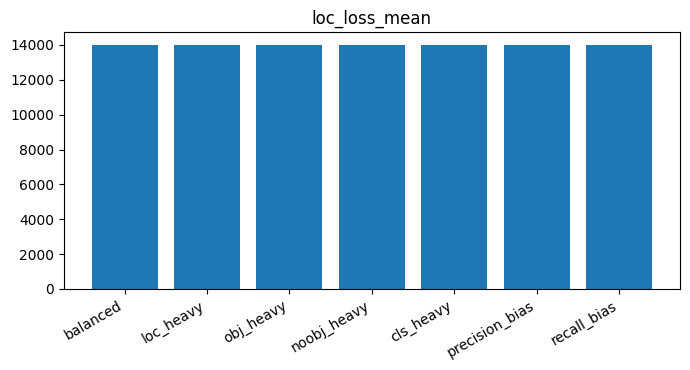

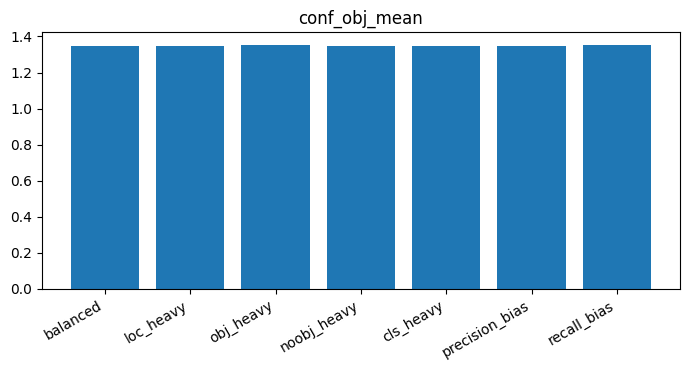

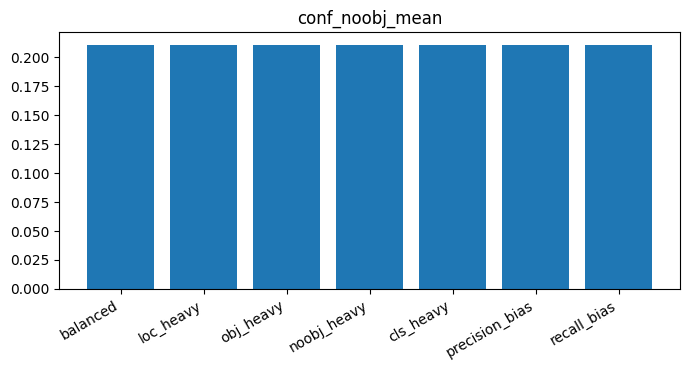

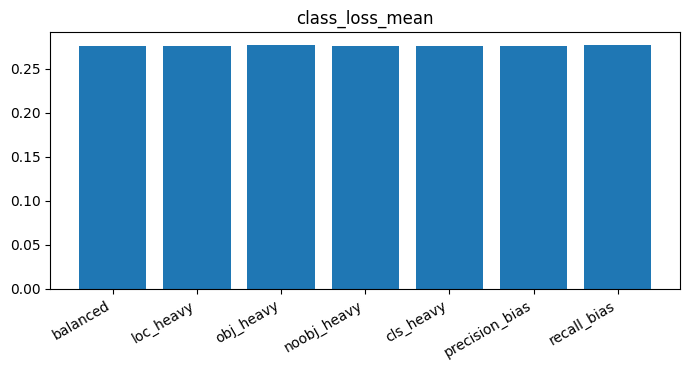

In [14]:
comp_rows = []
for cfg in lambda_df["config"].tolist():
    df_cfg_all = losses_df[losses_df["config"] == cfg].sort_values("total_loss", ascending=False)

    K = topk_from_percent(len(df_cfg_all), TOP_PCT)  # or include MIN_K
    df_cfg = df_cfg_all.head(K)

    comp_rows.append({
        "config": cfg,
        "K_selected": K,
        "loc_loss_mean": df_cfg["loc_loss"].mean(),
        "conf_obj_mean": df_cfg["conf_loss_obj"].mean(),
        "conf_noobj_mean": df_cfg["conf_loss_noobj"].mean(),
        "class_loss_mean": df_cfg["class_loss"].mean(),
    })

comp_df_plot = pd.DataFrame(comp_rows).set_index("config")
display(comp_df_plot)

# Bar plots (one plot per component)
for col in ["loc_loss_mean", "conf_obj_mean", "conf_noobj_mean", "class_loss_mean"]:
    plt.figure(figsize=(7,3.8))
    plt.bar(comp_df_plot.index, comp_df_plot[col])
    plt.xticks(rotation=30, ha="right")
    plt.title(col)
    plt.tight_layout()
    plt.show()


Across all λ configurations, the mined hard set has almost the same average component losses, which is why the selected images barely change. The key signal is the scale gap: ``loc_loss_mean ≈ 14023`` while the other components are around 1.35 (``obj``), 0.21 (``noobj``), and 0.28 (``cls``). This means the total loss (and therefore the HNM ranking) is effectively dominated by localization magnitude.

## 9) Estimating component scales and rerunning a λ sensitivity study

Because loss components differ by orders of magnitude, if we really want to determine the effect of each individual component we need to estimate their typical scale under a reference configuration and then normalize. Using these scales, we compute scale-compensated λ values (inverse of component magnitude) to reduce dominance by any single term and to make changes in λ meaningfully affect the hardness ranking. We then evaluate how sensitive the mined hard subset is to λ by reweighting per-image loss components without recomputing model predictions: starting from a baseline set of scale-compensated weights, we vary one λ at a time by a multiplier grid (0.25×, 0.5×, 1×, 2×, 4×), mine the Top \(10\%\) hardest images each time, and quantify changes via Jaccard overlap with the baseline selection and summary statistics.

In [15]:
try:
    TOP_PCT
except NameError:
    TOP_PCT = 0.10

comp_cols = ["loc_loss", "conf_loss_obj", "conf_loss_noobj", "class_loss"]

# Pick a reference config to estimate scales
ref_cfg = "balanced" if "balanced" in set(losses_df["config"]) else losses_df["config"].iloc[0]
ref_df = losses_df[losses_df["config"] == ref_cfg].copy()

# 1) Estimate typical scale (use median for robustness)
scales = ref_df[comp_cols].median()
print(f"Reference config for scale estimate: {ref_cfg}")
print("Median component scales:")
display(scales.to_frame("median_scale"))

# 2) Propose scale-compensated lambdas (inverse-scale, normalized to max=1)
eps = 1e-12
inv = 1.0 / (scales + eps)
lambdas = inv / inv.max()

lambda_coord = float(lambdas["loc_loss"])
lambda_obj   = float(lambdas["conf_loss_obj"])
lambda_noobj = float(lambdas["conf_loss_noobj"])
lambda_cls   = float(lambdas["class_loss"])

print("\nProposed scale-compensated lambdas (max=1.0):")
print({
    "lambda_coord": lambda_coord,
    "lambda_obj": lambda_obj,
    "lambda_noobj": lambda_noobj,
    "lambda_cls": lambda_cls
})

# 3) Re-rank using the rescaled lambdas (no recompute needed)
ref_df["reweighted_total_loss"] = (
    lambda_coord * ref_df["loc_loss"]
    + lambda_obj * ref_df["conf_loss_obj"]
    + lambda_noobj * ref_df["conf_loss_noobj"]
    + lambda_cls * ref_df["class_loss"]
)

K = int(np.ceil(float(TOP_PCT) * len(ref_df)))
K = max(1, min(K, len(ref_df)))

top_orig = set(ref_df.sort_values("total_loss", ascending=False).head(K)["image"])
top_rew  = set(ref_df.sort_values("reweighted_total_loss", ascending=False).head(K)["image"])

jacc = len(top_orig & top_rew) / max(1, len(top_orig | top_rew))
print(f"\nTop {int(TOP_PCT*100)}% overlap (orig vs scale-compensated): {jacc:.3f}")
print("Only in reweighted:", len(top_rew - top_orig))
print("Missing from reweighted:", len(top_orig - top_rew))

# 4) Check whether contributions become comparable
contrib = pd.DataFrame({
    "lambda*loc_loss": lambda_coord * ref_df["loc_loss"],
    "lambda*conf_obj": lambda_obj * ref_df["conf_loss_obj"],
    "lambda*conf_noobj": lambda_noobj * ref_df["conf_loss_noobj"],
    "lambda*class_loss": lambda_cls * ref_df["class_loss"],
})
print("\nMedian weighted contributions (should be more comparable):")
display(contrib.median().to_frame("median_weighted_contribution"))

Reference config for scale estimate: balanced
Median component scales:


,median_scale
loc_loss,638.500000
conf_loss_obj,0.210909
conf_loss_noobj,0.000000
class_loss,0.007369



Proposed scale-compensated lambdas (max=1.0):
{'lambda_coord': 1.5661707126076717e-15, 'lambda_obj': 4.741392179779915e-12, 'lambda_noobj': 1.0, 'lambda_cls': 1.3571102074434539e-10}

Top 10% overlap (orig vs scale-compensated): 0.067
Only in reweighted: 437
Missing from reweighted: 437

Median weighted contributions (should be more comparable):


,median_weighted_contribution
lambda*loc_loss,1.000000e-12
lambda*conf_obj,1.000000e-12
lambda*conf_noobj,0.000000e+00
lambda*class_loss,1.000000e-12


In [16]:
from collections import Counter

# λ Sensitivity Grid (scale-compensated, uses observed hard-set means)
# Requirements:
# - losses_df exists with columns:
#   ["config","image","total_loss","loc_loss","conf_loss_obj","conf_loss_noobj","class_loss"]
# - meta_df exists with columns:
#   ["image","gt_classes","num_objects","has_small_gt","unique_gt_classes"]
# - CLASS_NAMES exists (list of class names)

TOP_PCT = 0.10          # top 10% hardest
MULTS = [0.25, 0.5, 1, 2, 4]  # multipliers to probe sensitivity
REF_CFG = "balanced"    # use as base per-image values

# 1) Choose a scale reference: use the mean component magnitudes in the top TOP_PCT of REF_CFG
ref_all = losses_df[losses_df["config"] == REF_CFG].copy()
ref_all = ref_all.sort_values("total_loss", ascending=False)

K_ref = int(np.ceil(TOP_PCT * len(ref_all)))
K_ref = max(1, min(K_ref, len(ref_all)))
ref_top = ref_all.head(K_ref)

s_loc   = float(ref_top["loc_loss"].mean())
s_obj   = float(ref_top["conf_loss_obj"].mean())
s_noobj = float(ref_top["conf_loss_noobj"].mean())
s_cls   = float(ref_top["class_loss"].mean())

# Avoid division by zero (noobj can be tiny)
eps = 1e-12
base_lambdas = {
    "lambda_coord": 1.0 / max(s_loc, eps),
    "lambda_obj":   1.0 / max(s_obj, eps),
    "lambda_noobj": 1.0 / max(s_noobj, eps),
    "lambda_cls":   1.0 / max(s_cls, eps),
}

print("Scale reference (means in top set):")
print({"s_loc": s_loc, "s_obj": s_obj, "s_noobj": s_noobj, "s_cls": s_cls})
print("\nBaseline (scale-compensated) lambdas:")
print(base_lambdas)

# Helper: top-k for percent
def topk_from_percent(n, pct):
    return max(1, min(int(np.ceil(float(pct) * n)), n))

# Helper: summarize sampled set
def summarize_sample(sample_df, meta_df):
    m = sample_df.merge(meta_df, on="image", how="left")

    img_level_cls = Counter()
    for lst in m["unique_gt_classes"].dropna():
        for c in lst:
            img_level_cls[int(c)] += 1
    top_img_classes = sorted(img_level_cls.items(), key=lambda x: x[1], reverse=True)[:10]

    return {
        "n": int(len(m)),
        "avg_num_objects": float(m["num_objects"].mean()),
        "pct_small_gt": float(m["has_small_gt"].mean()),
        "top_gt_classes_img_level": [(CLASS_NAMES[c] if c < len(CLASS_NAMES) else str(c), n) for c, n in top_img_classes],
    }

def jaccard(a, b):
    return len(a & b) / max(1, len(a | b))

# 2) Use REF_CFG as the base per-image component values to reweight (no need to recompute Loss)
base_df = losses_df[losses_df["config"] == REF_CFG].copy()

# Baseline selection set
base_df["rew_total_base"] = (
    base_lambdas["lambda_coord"] * base_df["loc_loss"]
    + base_lambdas["lambda_obj"] * base_df["conf_loss_obj"]
    + base_lambdas["lambda_noobj"] * base_df["conf_loss_noobj"]
    + base_lambdas["lambda_cls"] * base_df["class_loss"]
)

K = topk_from_percent(len(base_df), TOP_PCT)
base_top = base_df.sort_values("rew_total_base", ascending=False).head(K).copy()
base_set = set(base_top["image"])

print(f"\nBaseline selection: top {int(TOP_PCT*100)}% = {K} images")

# 3) Build sensitivity grid: vary one λ at a time by MULTS
results = []
sets = {}

for focus in ["lambda_coord", "lambda_obj", "lambda_noobj", "lambda_cls"]:
    for mlt in MULTS:
        lam = base_lambdas.copy()
        lam[focus] = lam[focus] * float(mlt)

        col_name = f"rew_{focus}_x{mlt}"
        base_df[col_name] = (
            lam["lambda_coord"] * base_df["loc_loss"]
            + lam["lambda_obj"] * base_df["conf_loss_obj"]
            + lam["lambda_noobj"] * base_df["conf_loss_noobj"]
            + lam["lambda_cls"] * base_df["class_loss"]
        )

        top_df = base_df.sort_values(col_name, ascending=False).head(K).copy()
        sset = set(top_df["image"])
        sets[(focus, mlt)] = sset

        summ = summarize_sample(top_df[["image"]], meta_df)
        results.append({
            "focus_lambda": focus,
            "multiplier": mlt,
            "jaccard_vs_base": jaccard(base_set, sset),
            "only_in_variant": len(sset - base_set),
            "missing_from_variant": len(base_set - sset),
            "avg_num_objects": summ["avg_num_objects"],
            "pct_small_gt": summ["pct_small_gt"],
            "top_classes": summ["top_gt_classes_img_level"],  # keep for printing
        })

grid_df = pd.DataFrame(results).sort_values(["focus_lambda", "multiplier"])
display(grid_df[["focus_lambda","multiplier","jaccard_vs_base","only_in_variant","missing_from_variant","avg_num_objects","pct_small_gt"]])

# 4) Print the top class shifts for the most different variants (lowest Jaccard)
worst = grid_df.sort_values("jaccard_vs_base").head(6)
print("\nMost changed variants (lowest overlap):")
display(worst[["focus_lambda","multiplier","jaccard_vs_base","only_in_variant","missing_from_variant"]])

for _, row in worst.iterrows():
    print(f"\n=== Variant: {row['focus_lambda']} x{row['multiplier']} ===")
    print("Jaccard vs baseline:", f"{row['jaccard_vs_base']:.3f}")
    print("avg_num_objects:", f"{row['avg_num_objects']:.2f}", "| pct_small_gt:", f"{row['pct_small_gt']:.3f}")
    print("top classes (image-level count):")
    for name, cnt in row["top_classes"]:
        print(f"  {name}: {cnt}")

Scale reference (means in top set):
{'s_loc': 14023.444, 's_obj': 1.3488949894080706, 's_noobj': 0.2107417292720314, 's_cls': 0.27558909294995065}

Baseline (scale-compensated) lambdas:
{'lambda_coord': 7.130915914806662e-05, 'lambda_obj': 0.7413475532582602, 'lambda_noobj': 4.745144701309591, 'lambda_cls': 3.6285906285181198}

Baseline selection: top 10% = 500 images


,focus_lambda,multiplier,jaccard_vs_base,only_in_variant,missing_from_variant,avg_num_objects,pct_small_gt
15,lambda_cls,0.25,0.773050,64,64,12.348,0.802
16,lambda_cls,0.50,0.865672,36,36,12.488,0.794
17,lambda_cls,1.00,1.000000,0,0,12.374,0.768
18,lambda_cls,2.00,0.821494,49,49,12.190,0.724
19,lambda_cls,4.00,0.686341,93,93,12.040,0.702
0,lambda_coord,0.25,0.937984,16,16,12.434,0.780
1,lambda_coord,0.50,0.949318,13,13,12.434,0.778
2,lambda_coord,1.00,1.000000,0,0,12.374,0.768
3,lambda_coord,2.00,0.915709,22,22,12.358,0.742
4,lambda_coord,4.00,0.798561,56,56,12.242,0.716



Most changed variants (lowest overlap):


,focus_lambda,multiplier,jaccard_vs_base,only_in_variant,missing_from_variant
9,lambda_obj,4.00,0.572327,136,136
14,lambda_noobj,4.00,0.597444,126,126
10,lambda_noobj,0.25,0.680672,95,95
19,lambda_cls,4.00,0.686341,93,93
8,lambda_obj,2.00,0.727116,79,79
5,lambda_obj,0.25,0.736111,76,76



=== Variant: lambda_obj x4.0 ===
Jaccard vs baseline: 0.572
avg_num_objects: 13.02 | pct_small_gt: 0.888
top classes (image-level count):
  person: 249
  helmet: 134
  safety vest: 112
  wood pallet: 106
  fire: 73
  cardboard box: 60
  road sign: 44
  car: 40
  smoke: 28
  license plate: 24

=== Variant: lambda_noobj x4.0 ===
Jaccard vs baseline: 0.597
avg_num_objects: 10.63 | pct_small_gt: 0.664
top classes (image-level count):
  person: 212
  helmet: 111
  safety vest: 95
  wood pallet: 91
  cardboard box: 69
  car: 35
  road sign: 33
  forklift: 30
  traffic light: 27
  license plate: 26

=== Variant: lambda_noobj x0.25 ===
Jaccard vs baseline: 0.681
avg_num_objects: 12.72 | pct_small_gt: 0.804
top classes (image-level count):
  person: 257
  helmet: 150
  safety vest: 126
  wood pallet: 102
  cardboard box: 64
  car: 56
  road sign: 35
  van: 32
  fire: 30
  license plate: 28

=== Variant: lambda_cls x4.0 ===
Jaccard vs baseline: 0.686
avg_num_objects: 12.04 | pct_small_gt: 0.702

To correct the fact that our initial λ sweeps barely changed the mined hard set, we explicitly estimate the relative scales of the loss components and then reweight them so no single term dominates the hardness score by sheer magnitude. We experimented with scale-compensated λ values computed via inverse scaling: using median scales makes `conf_loss_noobj` problematic because its median is 0 (it is zero for at least half the images), so inverse-scaling over-emphasizes the no-object term and drastically changes the mined set (Top-10% overlap drops to ~0.067). We adopted a more stable scaling reference by using mean component magnitudes measured on the baseline hard set (top 10%), producing reasonable scale-compensated λ values. Varying one λ at a time now measurably changes the mined subset (lower Jaccard overlap), and the summaries show interpretable shifts in composition. In particular, increasing ``λ_obj`` (objectness-on-true-objects) shifts the hard set toward more crowded scenes and more small-object images (both ``avg_num_objects`` and ``pct_small_gt`` rise), which is consistent with mining images where the model tends to miss objects or assign low confidence, a recall-hard regime. Increasing ``λ_noobj`` (background/no-object penalty) produces the opposite pattern: the hard set becomes less dense and contains fewer small-object images, suggesting the mining focus moves toward false-positive-prone scenes (precision-hard cases). Increasing ``λ_cls`` (classification) changes the hard set moderately, indicating that misclassification-heavy images become more prominent when this term is emphasized. Finally, ``λ_coord`` (localization) has the smallest effect on subset membership, which is consistent with localization errors already being a major contributor to the overall loss signal even after scaling.


## Visualizing λ sensitivity

To make the λ sensitivity results easier to interpret, we visualize how key summary metrics change as we scale one λ at a time. Using the `grid_df` table, we plot: (1) Jaccard overlap vs baseline to quantify how much the mined hard set changes, (2) average number of objects per image to track whether mining shifts toward crowded scenes, and (3) fraction of images containing small GT objects (`pct_small_gt`) to track whether mining shifts toward small-object difficulty.

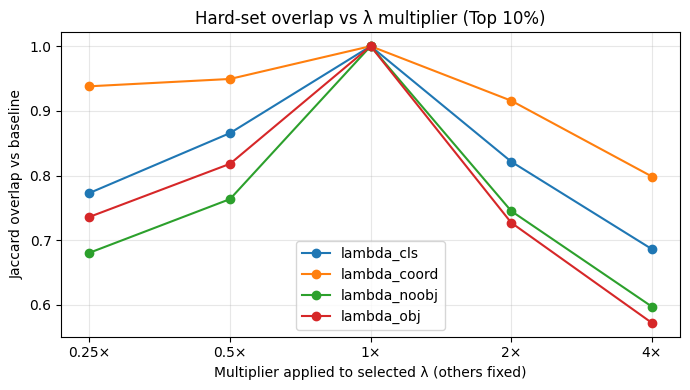

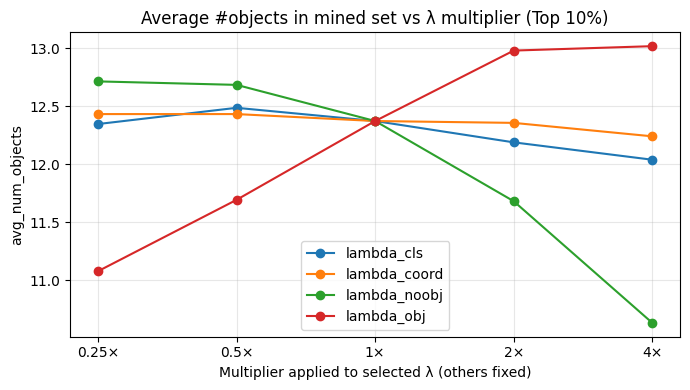

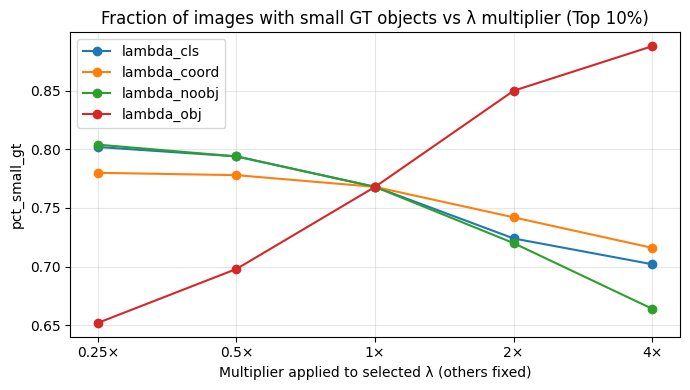

In [17]:
import matplotlib.pyplot as plt

# Ensure correct ordering on x-axis
grid_plot = grid_df.copy()
grid_plot["multiplier"] = grid_plot["multiplier"].astype(float)

def plot_metric(metric, title, ylabel):
    plt.figure(figsize=(7, 4))
    for lam in sorted(grid_plot["focus_lambda"].unique()):
        sub = grid_plot[grid_plot["focus_lambda"] == lam].sort_values("multiplier")
        plt.plot(sub["multiplier"], sub[metric], marker="o", label=lam)
    plt.xscale("log", base=2)   # since multipliers are 0.25,0.5,1,2,4
    plt.xticks([0.25, 0.5, 1, 2, 4], ["0.25×", "0.5×", "1×", "2×", "4×"])
    plt.title(title)
    plt.xlabel("Multiplier applied to selected λ (others fixed)")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_metric(
    metric="jaccard_vs_base",
    title=f"Hard-set overlap vs λ multiplier (Top {int(TOP_PCT*100)}%)",
    ylabel="Jaccard overlap vs baseline"
)

plot_metric(
    metric="avg_num_objects",
    title=f"Average #objects in mined set vs λ multiplier (Top {int(TOP_PCT*100)}%)",
    ylabel="avg_num_objects"
)

plot_metric(
    metric="pct_small_gt",
    title=f"Fraction of images with small GT objects vs λ multiplier (Top {int(TOP_PCT*100)}%)",
    ylabel="pct_small_gt"
)

**Hard-set overlap (Jaccard) plot:** At 1× all curves meet at 1.0 because that is the baseline selection. Moving away from 1× shows which λ has the strongest effect on which images enter the Top-10% hard subset. The biggest drops in overlap happen when we change ``λ_obj`` (red) and ``λ_noobj`` (green), meaning those weights most strongly change which images are considered hard. ``λ_coord`` (orange) changes the set the least (higher overlap across multipliers), and ``λ_cls`` (blue) is in between. This is exactly what we expect if objectness/no-objectness are the knobs that most change hardness type (FN-heavy vs FP-heavy), while localization stays relatively stable.

**Average #objects plot:** As ``λ_obj`` increases, the mined set becomes denser (avg objects rises from ~11.1 at 0.25× to ~13.0 at 4×). This fits the intuition: emphasizing objectness-on-true-objects prioritizes images where the model struggles to confidently detect real objects—dense scenes with many objects are more likely to contain missed detections or low-confidence detections. As ``λ_noobj`` increases, the mined set becomes less dense (avg objects drops sharply to ~10.6 at 4×). This also makes sense: emphasizing the no-object term penalizes false positives, which often come from background clutter or confusing patterns rather than simply having lots of labeled objects. So the selected hard images shift away from highly populated scenes and toward FP-prone backgrounds.

**Fraction small-object plot:** As ``λ_obj`` increases, ``pct_small_gt`` rises strongly (~ 0.65 → ~ 0.89). That is very intuitive: small objects are harder to detect reliably, so if we weight objectness errors more, images containing small targets become much more likely to rank as hard. As ``λ_noobj`` increases, ``pct_small_gt`` decreases (~0.80 → ~0.66). Again intuitive: the no-object term pushes the mining focus toward false positives, which does not necessarily correlate with the presence of small ground truth objects (and may even prioritize backgrounds where small ground truth are absent).

Earlier, we said the initial λ sweeps did not change sampling because one large-scale term dominated. After scale compensation, the plots show λ behaves like a real control:

- ``λ_obj`` up → recall-hard set (more crowded, more small objects, bigger change in membership).

- ``λ_noobj`` up → precision-hard set (fewer objects, fewer small-object images, big change in membership).

- ``λ_cls`` and ``λ_coord`` have more moderate effects.
